# Notebook 3: NLP & Structural Feature Engineering
Produces `features.parquet` with all features needed for modeling.

**Runtime tip:** Enable GPU in Colab (Runtime > Change runtime type > T4 GPU) before running sentence embeddings.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE    = '/content/drive/MyDrive/Social_Media_Mining_Project'
OUT_DIR = f'{BASE}/outputs/'
FIG_DIR = f'{BASE}/figures/'

Mounted at /content/drive


In [2]:
!pip install sentence-transformers textstat vaderSentiment -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 90.8 MB/s eta 0:00:00


In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import textstat
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sentence_transformers import SentenceTransformer

def set_all_seeds(seed=6):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
set_all_seeds(6)

In [4]:
df = pd.read_parquet(f'{OUT_DIR}master_clean.parquet')
print('Loaded:', df.shape)

Loaded: (49238, 30)


## 3.1 Title-based lexical features

In [5]:
def extract_title_features(df):
    """
    Extract surface-level features from the post title:
      title_len          : character count
      title_word_count   : word count
      title_caps_ratio   : fraction of uppercase characters
      title_has_question : 1 if title ends with '?'
      title_has_exclaim  : 1 if title contains '!'
      title_num_digits   : count of digit characters
      title_readability  : Flesch-Kincaid reading ease (higher = easier to read)
    """
    df = df.copy()
    titles = df['title'].fillna('').astype(str)

    df['title_len']          = titles.str.len()
    df['title_word_count']   = titles.str.split().str.len()
    df['title_caps_ratio']   = titles.apply(
        lambda t: sum(c.isupper() for c in t) / max(len(t), 1)
    )
    df['title_has_question'] = titles.str.strip().str.endswith('?').astype(int)
    df['title_has_exclaim']  = titles.str.contains('!').astype(int)
    df['title_num_digits']   = titles.apply(lambda t: sum(c.isdigit() for c in t))
    df['title_readability']  = titles.apply(
        lambda t: textstat.flesch_reading_ease(t) if len(t.split()) >= 3 else 0.0
    )

    return df

df = extract_title_features(df)
title_feat_cols = ['title_len','title_word_count','title_caps_ratio',
                   'title_has_question','title_has_exclaim',
                   'title_num_digits','title_readability']
print(df[title_feat_cols].describe().round(3))

       title_len  title_word_count  title_caps_ratio  title_has_question  \
count  49238.000         49238.000         49238.000           49238.000   
mean      92.988            16.175             0.062               0.099   
std       68.081            11.918             0.058               0.299   
min        1.000             1.000             0.000               0.000   
25%       46.000             8.000             0.024               0.000   
50%       73.000            13.000             0.044               0.000   
75%      116.000            21.000             0.083               0.000   
max      300.000            67.000             1.000               1.000   

       title_has_exclaim  title_num_digits  title_readability  
count          49238.000         49238.000          49238.000  
mean               0.054             1.381             62.481  
std                0.225             2.505             26.843  
min                0.000             0.000           -219.2

## 3.2 Sentiment features (VADER)

VADER is specifically designed for social media text — ideal for Reddit titles.

In [6]:
def extract_sentiment_features(df):
    """
    VADER sentiment on title:
      sentiment_compound : overall sentiment (-1 to 1)
      sentiment_positive : positive component
      sentiment_negative : negative component
      sentiment_neutral  : neutral component
    """
    df = df.copy()
    analyzer = SentimentIntensityAnalyzer()
    titles = df['title'].fillna('').astype(str)

    scores = titles.apply(lambda t: analyzer.polarity_scores(t))
    df['sentiment_compound'] = scores.apply(lambda s: s['compound'])
    df['sentiment_positive'] = scores.apply(lambda s: s['pos'])
    df['sentiment_negative'] = scores.apply(lambda s: s['neg'])
    df['sentiment_neutral']  = scores.apply(lambda s: s['neu'])

    return df

df = extract_sentiment_features(df)
sent_cols = ['sentiment_compound','sentiment_positive','sentiment_negative','sentiment_neutral']
print(df[sent_cols].describe().round(3))

       sentiment_compound  sentiment_positive  sentiment_negative  \
count           49238.000           49238.000           49238.000   
mean                0.024               0.086               0.072   
std                 0.396               0.140               0.124   
min                -0.983               0.000               0.000   
25%                -0.128               0.000               0.000   
50%                 0.000               0.000               0.000   
75%                 0.296               0.145               0.121   
max                 0.983               1.000               1.000   

       sentiment_neutral  
count          49238.000  
mean               0.842  
std                0.174  
min                0.000  
25%                0.735  
50%                0.872  
75%                1.000  
max                1.000  


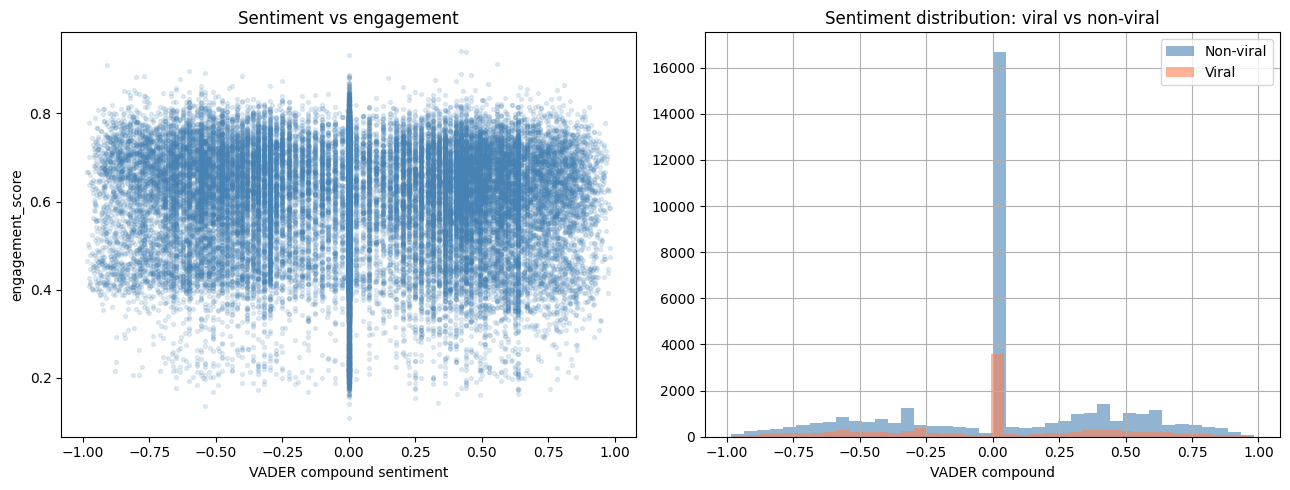

In [7]:
# Visualize: sentiment compound vs engagement
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['sentiment_compound'], df['engagement_score'],
                alpha=0.15, s=8, color='steelblue')
axes[0].set_xlabel('VADER compound sentiment')
axes[0].set_ylabel('engagement_score')
axes[0].set_title('Sentiment vs engagement')

# Viral vs non-viral sentiment distribution
df[df['is_viral']==0]['sentiment_compound'].hist(
    bins=40, alpha=0.6, color='steelblue', label='Non-viral', ax=axes[1])
df[df['is_viral']==1]['sentiment_compound'].hist(
    bins=40, alpha=0.6, color='coral', label='Viral', ax=axes[1])
axes[1].set_title('Sentiment distribution: viral vs non-viral')
axes[1].set_xlabel('VADER compound')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}03_sentiment_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Structural features

In [8]:
def extract_structural_features(df):
    """
    Structural / metadata features:
      is_external_link   : url domain is not reddit/i.redd.it/v.redd.it
      has_body_text      : post has non-empty body (text post with content)
      body_len           : length of body text
      is_nsfw            : already a bool, cast to int
      is_megathread      : already a bool, cast to int
      num_crossposts     : already in dataset
      post_type_*        : one-hot dummies for post_type
    """
    df = df.copy()

    reddit_domains = {'self.', 'i.redd.it', 'v.redd.it', 'reddit.com', 'www.reddit.com'}
    df['is_external_link'] = df['domain'].apply(
        lambda d: 0 if any(rd in str(d) for rd in reddit_domains) else 1
    )
    df['has_body_text'] = (df['body'].str.strip().str.len() > 0).astype(int)
    df['body_len']      = df['body'].str.len()
    df['is_nsfw_int']   = df['is_nsfw'].astype(int)
    df['is_mega_int']   = df['is_megathread'].astype(int)

    # One-hot post type
    post_dummies = pd.get_dummies(df['post_type'], prefix='ptype').astype(int)
    df = pd.concat([df, post_dummies], axis=1)

    return df

df = extract_structural_features(df)
struct_cols = ['is_external_link','has_body_text','body_len',
               'is_nsfw_int','is_mega_int','num_crossposts']
print(df[struct_cols].describe().round(3))

       is_external_link  has_body_text   body_len  is_nsfw_int  is_mega_int  \
count         49238.000      49238.000  49238.000    49238.000     49238.00   
mean              0.429          0.172    268.504        0.024         0.00   
std               0.495          0.377   1141.895        0.153         0.02   
min               0.000          0.000      0.000        0.000         0.00   
25%               0.000          0.000      0.000        0.000         0.00   
50%               0.000          0.000      0.000        0.000         0.00   
75%               1.000          0.000      0.000        0.000         0.00   
max               1.000          1.000  39972.000        1.000         1.00   

       num_crossposts  
count       49238.000  
mean            8.383  
std            13.611  
min             0.000  
25%             1.000  
50%             4.000  
75%            11.000  
max           481.000  


## 3.4 Subreddit-level prior features

For each subreddit, compute its mean engagement score across all posts.
This captures the 'baseline difficulty' of going viral in a given community.

In [13]:
# Drop if already exists (safe to re-run)
df = df.drop(columns=['sub_mean_engagement', 'sub_viral_rate'], errors='ignore')

sub_means = df.groupby('subreddit')['engagement_score'].mean().rename('sub_mean_engagement')
sub_viral = df.groupby('subreddit')['is_viral'].mean().rename('sub_viral_rate')
df = df.join(sub_means, on='subreddit')
df = df.join(sub_viral, on='subreddit')
print(f"sub_mean_engagement range: {df['sub_mean_engagement'].min():.4f} - {df['sub_mean_engagement'].max():.4f}")

sub_mean_engagement range: 0.2565 - 0.7748


## 3.5 Sentence embeddings (transformer model)

This uses `all-MiniLM-L6-v2` — the same model from HW3. Each title becomes a 384-dim vector.
We save the embeddings separately as a `.npy` file to avoid recomputing.

In [14]:
EMBED_PATH = f'{OUT_DIR}title_embeddings.npy'

if os.path.exists(EMBED_PATH):
    print('Loading cached embeddings...')
    embeddings = np.load(EMBED_PATH)
    print('Loaded embeddings shape:', embeddings.shape)
else:
    print('Computing embeddings (enable GPU for speed)...')
    model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
    titles = df['title'].fillna('').astype(str).tolist()
    embeddings = model.encode(
        titles,
        batch_size=128,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBED_PATH, embeddings)
    print(f'Saved embeddings to {EMBED_PATH}')
    print('Embeddings shape:', embeddings.shape)

Computing embeddings (enable GPU for speed)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/385 [00:00<?, ?it/s]

Saved embeddings to /content/drive/MyDrive/Social_Media_Mining_Project/outputs/title_embeddings.npy
Embeddings shape: (49238, 384)


In [15]:
# Reduce embeddings to 50 dims with PCA for use as tabular features in XGBoost
from sklearn.decomposition import PCA

N_COMPONENTS = 50
pca = PCA(n_components=N_COMPONENTS, random_state=6)
embed_pca = pca.fit_transform(embeddings)
print(f'PCA: {embeddings.shape[1]}D -> {N_COMPONENTS}D')
print(f'Explained variance: {pca.explained_variance_ratio_.sum():.3f}')

embed_cols = [f'emb_{i}' for i in range(N_COMPONENTS)]
embed_df   = pd.DataFrame(embed_pca, columns=embed_cols, index=df.index)
df = pd.concat([df, embed_df], axis=1)
print('Added embedding features. df shape:', df.shape)

PCA: 384D -> 50D
Explained variance: 0.457
Added embedding features. df shape: (49238, 102)


## 3.6 Save feature dataframe

In [16]:
# Define final feature groups for use in Step 4 modeling
FEATURE_GROUPS = {
    'text_lexical': [
        'title_len','title_word_count','title_caps_ratio',
        'title_has_question','title_has_exclaim',
        'title_num_digits','title_readability',
        'sentiment_compound','sentiment_positive',
        'sentiment_negative','sentiment_neutral'
    ],
    'text_semantic': embed_cols,   # 50 PCA dims of SBERT embeddings
    'structural': [
        'is_external_link','has_body_text','body_len',
        'is_nsfw_int','is_mega_int','num_crossposts',
        'hour','day_of_week','is_weekend','month',
        'sub_mean_engagement','sub_viral_rate'
    ] + [c for c in df.columns if c.startswith('ptype_')],
}

import json
with open(f'{OUT_DIR}feature_groups.json', 'w') as f:
    json.dump(FEATURE_GROUPS, f, indent=2)
print('Feature groups saved.')

out_path = f'{OUT_DIR}features.parquet'
df.to_parquet(out_path, index=False)
print(f'Features saved -> {out_path}')
print('Total features per group:')
for grp, cols in FEATURE_GROUPS.items():
    print(f'  {grp}: {len(cols)} features')
print(f'  COMBINED: {sum(len(v) for v in FEATURE_GROUPS.values())} features')

Feature groups saved.
Features saved -> /content/drive/MyDrive/Social_Media_Mining_Project/outputs/features.parquet
Total features per group:
  text_lexical: 11 features
  text_semantic: 50 features
  structural: 16 features
  COMBINED: 77 features
